In [17]:
!pip install -q jupyterlab matplotlib ipywidgets
!pip install -q -r requirements.txt

In [18]:
import time
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

import data   # data.py из этой папки: качает и кеширует клипы FLEURS

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEVICE)


device: mps


In [19]:
# один раз скачает 12 клипов на каждый язык (~13 МБ) в audio/
try:
    clips_kk = data.clips("kk")
except SystemExit:
    data.fetch(("kk", "ru", "en"), n=12)
    clips_kk = data.clips("kk")

clip = clips_kk[0]
y, sr = data.load_audio(clip)

print("%s — %.1f с, %s" % (clip["file"], clip["seconds"], clip["source"]))
print("эталон:", clip["reference"])
display(Audio(y, rate=sr))


kk-00.wav — 14.9 с, google/fleurs kk_kz test
эталон: ақш-тың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және біздің барлық спортсмендер үшін қоршаған ортаның қауіпсіздігін арттырудың абсолютті қажеттілігін мойындайды


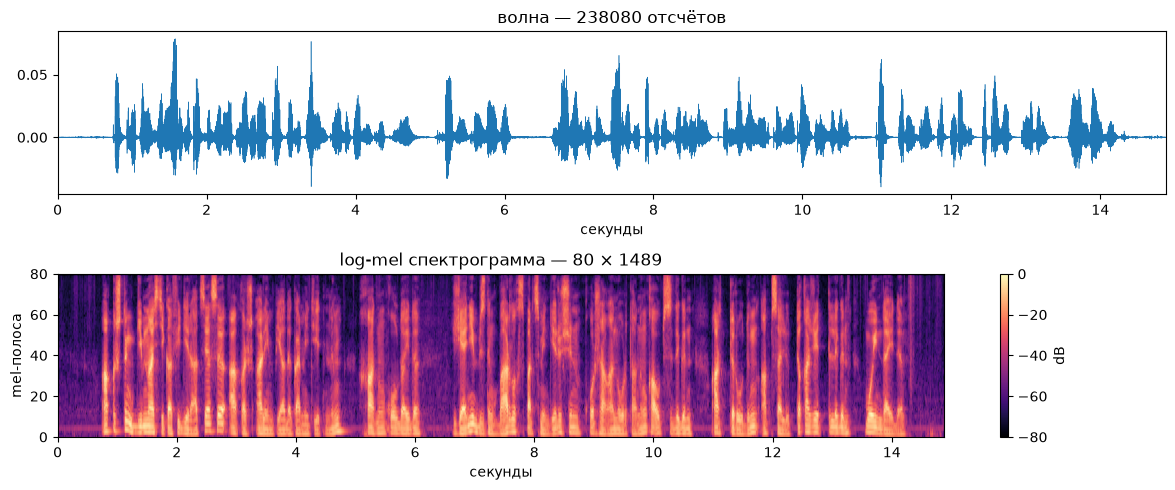

14.88 с → 1489 кадров = 100 кадров/с (шаг 160 отсчётов = 10 мс)


In [20]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=400, hop_length=160, n_mels=80)
db = librosa.power_to_db(mel, ref=np.max)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=False)
ax[0].plot(np.arange(len(y)) / sr, y, linewidth=0.4)
ax[0].set(title="волна — %d отсчётов" % len(y), xlabel="секунды", xlim=(0, len(y)/sr))
im = ax[1].imshow(db, aspect="auto", origin="lower", cmap="magma",
                  extent=[0, len(y)/sr, 0, 80])
ax[1].set(title="log-mel спектрограмма — %d × %d" % db.shape,
          xlabel="секунды", ylabel="mel-полоса")
plt.colorbar(im, ax=ax[1], label="dB"); plt.tight_layout(); plt.show()

print("%.2f с → %d кадров = %.0f кадров/с (шаг 160 отсчётов = 10 мс)"
      % (len(y)/sr, db.shape[1], db.shape[1] / (len(y)/sr)))


In [21]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

proc = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to(DEVICE).eval()

def transcribe(samples, sr=16000, language="kk", task="transcribe", max_new_tokens=220):
    feats = proc(samples, sampling_rate=sr, return_tensors="pt").input_features.to(DEVICE)
    t0 = time.time()
    with torch.no_grad():
        ids = model.generate(feats, language=language, task=task, max_new_tokens=max_new_tokens)
    return proc.batch_decode(ids, skip_special_tokens=True)[0].strip(), time.time() - t0

text, took = transcribe(y, sr, language="kk")
print("whisper:", text)
print("\n%.1f с на %.1f с аудио — RTF %.2f" % (took, len(y)/sr, took / (len(y)/sr)))


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


whisper: Ақыштың димнастика федерациясы Ақыш Олимпиады қамитетінің ханғылдайды, және біздің барлық спартсмендерішін, хоршаған үртаның қаупсыдың, арттырудың абсалюттық ажеттілің бойындайды.

0.9 с на 14.9 с аудио — RTF 0.06


Original: эталон: ақш-тың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және біздің барлық спортсмендер үшін қоршаған ортаның қауіпсіздігін арттырудың абсолютті қажеттілігін мойындайды

Whisper: Ақыштың димнастика федерациясы Ақыш Олимпиады қамитетінің ханғылдайды, және біздің барлық спартсмендерішін, хоршаған үртаның қаупсыдың, арттырудың абсалюттық ажеттілің бойындайды.

In [22]:
import re, unicodedata, jiwer

def normalise(t):
    t = unicodedata.normalize("NFC", str(t)).lower()
    t = re.sub(r"[^\w\s]", " ", t, flags=re.UNICODE)
    return re.sub(r"\s+", " ", t).strip()

ref, hyp = normalise(clip["reference"]), normalise(text)
o = jiwer.process_words(ref, hyp)

print("WER %.3f   CER %.3f" % (o.wer, jiwer.cer(ref, hyp)))
print("замен %d, пропусков %d, вставок %d, попаданий %d, слов в эталоне %d"
      % (o.substitutions, o.deletions, o.insertions, o.hits, len(ref.split())))

import difflib
for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(a=ref.split(), b=hyp.split()).get_opcodes():
    if tag != "equal":
        print("  %-8s %-32s → %s" % (tag, " ".join(ref.split()[i1:i2])[:32] or "—",
                                          " ".join(hyp.split()[j1:j2])[:32] or "—"))


WER 0.762   CER 0.174
замен 13, пропусков 3, вставок 0, попаданий 5, слов в эталоне 21
  replace  ақш тың гимнастика               → ақыштың димнастика
  replace  ақш олимпиада комитетінің хатын  → ақыш олимпиады қамитетінің ханғы
  replace  спортсмендер үшін қоршаған ортан → спартсмендерішін хоршаған үртаны
  replace  абсолютті қажеттілігін мойындайд → абсалюттық ажеттілің бойындайды


In [7]:
enc = model.model.encoder
feats = proc(y, sampling_rate=sr, return_tensors="pt").input_features.to(DEVICE)

print("input_features ", tuple(feats.shape), "= (batch, 80 mel, 3000 кадров = 30 с)")
h = torch.nn.functional.gelu(enc.conv1(feats)); print("после conv1    ", tuple(h.shape))
h = torch.nn.functional.gelu(enc.conv2(h));     print("после conv2    ", tuple(h.shape), "← stride 2")
with torch.no_grad():
    out = enc(feats).last_hidden_state
print("выход encoder  ", tuple(out.shape), "→ %.0f кадров/с, %.0f мс на кадр"
      % (out.shape[1] / 30, 30000 / out.shape[1]))
print("\nencoder %.1f M   decoder %.1f M параметров"
      % (sum(p.numel() for p in enc.parameters())/1e6,
         sum(p.numel() for p in model.model.decoder.parameters())/1e6))


input_features  (1, 80, 3000) = (batch, 80 mel, 3000 кадров = 30 с)
после conv1     (1, 768, 3000)
после conv2     (1, 768, 1500) ← stride 2
выход encoder   (1, 1500, 768) → 50 кадров/с, 20 мс на кадр

encoder 88.2 M   decoder 153.6 M параметров


In [8]:
for lang in ("kk", "ru", "tr", "en"):
    t, _ = transcribe(y, sr, language=lang)
    print("language=%-3s WER %.3f  %s" % (lang, jiwer.wer(ref, normalise(t)), t[:90]))


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


language=kk  WER 0.762  Ақыштың димнастика федерациясы Ақыш Олимпиады қамитетінің ханғылдайды, және біздің барлық 


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


language=ru  WER 0.905  Акшн димнастика Федерация Акш Олимпиада комитетов, хану кольда, жени битвам барлык спортсм


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


language=tr  WER 1.095  Akıştın Dimyastika Fidiratiası Akış Aleyküya'da komite etmeli, kanun koldaydı. Yani bizdek
language=en  WER 1.095  The Dymnastic Federation was the chairman of the Olympic Committee. It was the center of t


In [9]:
for task in ("transcribe", "translate"):
    t, took = transcribe(y, sr, language="kk", task=task)
    print("\ntask=%s (%.1f с)\n  %s" % (task, took, t[:200]))


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



task=transcribe (0.7 с)
  Ақыштың димнастика федерациясы Ақыш Олимпиады қамитетінің ханғылдайды, және біздің барлық спартсмендерішін, хоршаған үртаның қаупсыдың, арттырудың абсалюттық ажеттілің бойындайды.

task=translate (0.3 с)
  The Dymnastic Federation of Akhars is the leader of the Akhars Olympic Committee. It is the center of the community of our sportsmen, athletes, and athletes.


In [10]:
rows = {}
for lang in ("en", "ru", "kk"):
    wers, cers, audio_s, gen_s = [], [], [], []
    for c in data.clips(lang):
        s, r = data.load_audio(c)
        t, took = transcribe(s, r, language=lang)
        a, b = normalise(c["reference"]), normalise(t)
        wers.append(jiwer.wer(a, b)); cers.append(jiwer.cer(a, b))
        audio_s.append(c["seconds"]); gen_s.append(took)
    rows[lang] = (np.mean(wers), np.mean(cers), sum(gen_s)/sum(audio_s))
    print("%-4s WER %.3f  CER %.3f  RTF %.2f" % ((lang,) + rows[lang]))

print("\nказахский WER в %.1f× больше английского, а CER — только в %.1f×"
      % (rows["kk"][0]/rows["en"][0], rows["kk"][1]/rows["en"][1]))


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

en   WER 0.099  CER 0.042  RTF 0.03


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

ru   WER 0.108  CER 0.028  RTF 0.03


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

kk   WER 0.744  CER 0.180  RTF 0.04

казахский WER в 7.5× больше английского, а CER — только в 4.3×


In [11]:
for size in ("tiny", "base", "small"):
    p = WhisperProcessor.from_pretrained("openai/whisper-%s" % size)
    m = WhisperForConditionalGeneration.from_pretrained("openai/whisper-%s" % size).to(DEVICE).eval()
    wers, cers = [], []
    for c in data.clips("kk"):
        s, r = data.load_audio(c)
        f = p(s, sampling_rate=r, return_tensors="pt").input_features.to(DEVICE)
        with torch.no_grad():
            ids = m.generate(f, language="kk", task="transcribe", max_new_tokens=220)
        t = normalise(p.batch_decode(ids, skip_special_tokens=True)[0])
        a = normalise(c["reference"])
        wers.append(jiwer.wer(a, t)); cers.append(jiwer.cer(a, t))
    print("%-6s %.1f M  WER %.3f  CER %.3f"
          % (size, sum(x.numel() for x in m.parameters())/1e6, np.mean(wers), np.mean(cers)))
    del m


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

tiny   37.8 M  WER 2.099  CER 0.894


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

base   72.6 M  WER 0.934  CER 0.322


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

small  241.7 M  WER 0.744  CER 0.180


In [12]:
from omnivoice import OmniVoice

tts = OmniVoice.from_pretrained("k2-fsa/OmniVoice", device_map=DEVICE, dtype=torch.float32)
SR_TTS = 24000

def speak(text, language="Kazakh", **kw):
    t0 = time.time()
    audio = tts.generate(text=text, language=language, **kw)[0]
    took = time.time() - t0
    print("%.2f с аудио за %.1f с (RTF %.2f)" % (len(audio)/SR_TTS, took, took/(len(audio)/SR_TTS)))
    display(Audio(audio, rate=SR_TTS))
    return audio


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/313 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/527 [00:00<?, ?it/s]

In [13]:
at = tts.audio_tokenizer
for secs in (1, 2, 4):
    with torch.no_grad():
        codes = at.encode(torch.zeros(1, 1, SR_TTS * secs))
    c = codes[0] if isinstance(codes, (tuple, list)) else codes
    c = getattr(c, "audio_codes", c)
    print("%d с → codes %-14s  %.0f кадров/с, %d кодовых книг, %d целых всего"
          % (secs, str(tuple(c.shape)), c.shape[-1]/secs, c.shape[-2], c.shape[-1]*c.shape[-2]))
print("\n25 × 8 × 10 бит = 2000 бит/с — из 24 000 чисел в секунду")


1 с → codes (1, 8, 25)      25 кадров/с, 8 кодовых книг, 200 целых всего
2 с → codes (1, 8, 50)      25 кадров/с, 8 кодовых книг, 400 целых всего
4 с → codes (1, 8, 100)     25 кадров/с, 8 кодовых книг, 800 целых всего

25 × 8 × 10 бит = 2000 бит/с — из 24 000 чисел в секунду


In [14]:
line = "Сәлеметсіз бе! Бүгін Астанада ауа райы жақсы."

print("auto:");                       a1 = speak(line)
print("\nvoice design — молодая:");   a2 = speak(line, instruct="female, young adult, high pitch")
print("\nvoice design — пожилой:");   a3 = speak(line, instruct="male, elderly, low pitch")

print("\nvoice clone с диктора FLEURS:")
a4 = speak(line, ref_audio=data.path(clip), ref_text=clip["reference"])


auto:
2.96 с аудио за 3.5 с (RTF 1.17)



voice design — молодая:
2.96 с аудио за 2.5 с (RTF 0.86)



voice design — пожилой:
2.96 с аудио за 2.5 с (RTF 0.84)



voice clone с диктора FLEURS:
3.56 с аудио за 13.6 с (RTF 3.83)


In [15]:
SENTENCES = {
    "kk": ["Сәлеметсіз бе! Бүгін Астанада ауа райы жақсы.",
           "Алматыдан Шымкентке дейінгі жол тоғыз сағат."],
    "ru": ["Здравствуйте! Сегодня в Астане хорошая погода.",
           "Дорога из Алматы в Шымкент занимает девять часов."],
    "en": ["Hello! The weather in Astana is good today.",
           "The road from Almaty to Shymkent takes nine hours."],
}
NAMES = {"kk": "Kazakh", "ru": "Russian", "en": "English"}
HUMAN = {"en": 0.099, "ru": 0.108, "kk": 0.744}   # Whisper на живой речи, из ячейки 10

for lang, lines in SENTENCES.items():
    wers = []
    for s in lines:
        audio = tts.generate(text=s, language=NAMES[lang])[0]
        back = librosa.resample(np.asarray(audio, dtype=np.float32),
                                orig_sr=SR_TTS, target_sr=16000)
        heard, _ = transcribe(back, 16000, language=lang)
        wers.append(jiwer.wer(normalise(s), normalise(heard)))
    print("%-4s круговой рейс WER %.3f   (Whisper на живой речи: %.3f)"
          % (lang, np.mean(wers), HUMAN[lang]))


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


kk   круговой рейс WER 0.929   (Whisper на живой речи: 0.744)


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ru   круговой рейс WER 0.292   (Whisper на живой речи: 0.108)


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


en   круговой рейс WER 0.056   (Whisper на живой речи: 0.099)


In [16]:
target = "Алматыдан Шымкентке дейінгі жол тоғыз сағат."
heard_ref, _ = transcribe(y, sr, language="kk")   # что Whisper услышал в референсе

for label, ref_text in (("верная расшифровка", clip["reference"]),
                        ("расшифровка Whisper", heard_ref)):
    audio = tts.generate(text=target, language="Kazakh",
                         ref_audio=data.path(clip), ref_text=ref_text)[0]
    back = librosa.resample(np.asarray(audio, dtype=np.float32),
                            orig_sr=SR_TTS, target_sr=16000)
    got, _ = transcribe(back, 16000, language="kk")
    print("ref_text = %-22s → WER %.3f" % (label, jiwer.wer(normalise(target), normalise(got))))
    display(Audio(audio, rate=SR_TTS))


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ref_text = верная расшифровка     → WER 0.833


[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ref_text = расшифровка Whisper    → WER 0.833
